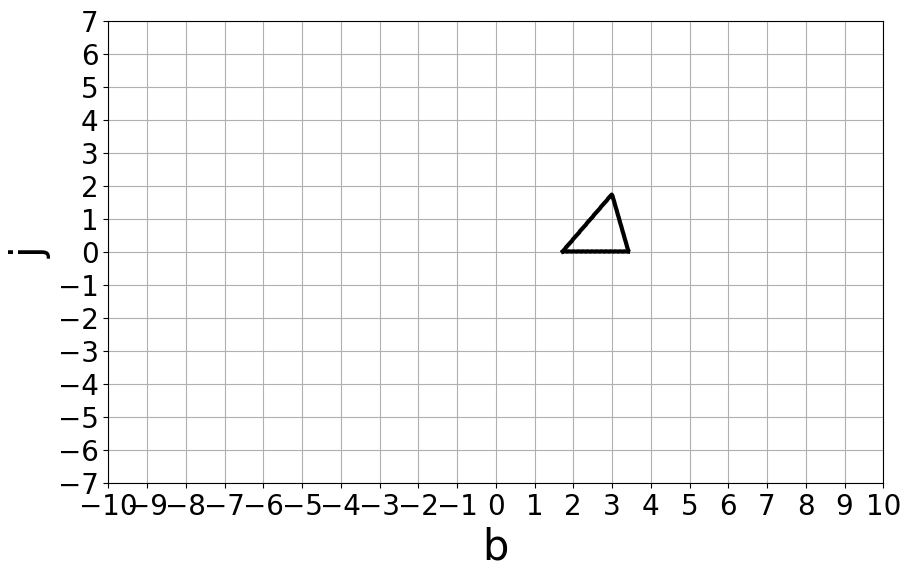

[0 0 2 0 0 0]


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import MultipleLocator

def list_to_python_syntax(lst):
    result = "[" + ", ".join(str(item) for item in lst) + "]"
    return result

def plot_results(Ic_max, Ic_min, vorticity, MagField):

    colors = ['black'] # Example Colors

    plt.figure(figsize=(10, 6))
    x_locator = MultipleLocator(1)  # X-axis ticks at integer multiples
    y_locator = MultipleLocator(1)  # Y-axis ticks at integer multiples
    ax = plt.gca()
    ax.xaxis.set_major_locator(x_locator)
    ax.yaxis.set_major_locator(y_locator)
    for i in range(len(Ic_max)):
        if np.sum(np.array(vorticity[i])) % 4 == 0:
            # print(np.sum(vorticity[i]))
            plt.plot(MagField, Ic_max[i], label=f"v_n = {list_to_python_syntax(vorticity[i])}", color='black', linewidth=3)
            plt.plot(MagField, Ic_min[i], color='black', linewidth=3)
            continue
        if np.abs(vorticity[i][0]) == 1 or np.abs(vorticity[i][3]) == 1:
            plt.plot(MagField, Ic_max[i], label=f"v_n = {list_to_python_syntax(vorticity[i])}", color='black', linewidth=3)
            plt.plot(MagField, Ic_min[i], color='black', linewidth=3)
            continue
        if np.abs(vorticity[i][1]) == 1 or np.abs(vorticity[i][2]) == 1:
            plt.plot(MagField, Ic_max[i], label=f"v_n = {list_to_python_syntax(vorticity[i])}", color='black', linewidth=3)
            plt.plot(MagField, Ic_min[i], color='black', linewidth=3)
        else:
            plt.plot(MagField, Ic_max[i], label=f"v_n = {list_to_python_syntax(vorticity[i])}", color='black', linewidth=3)
            plt.plot(MagField, Ic_min[i], color='black', linewidth=3)
    # plt.legend(loc="upper right") # If the legend gets too long, comment the above line out
    plt.xlim(-10,10)
    plt.ylim(-7,7)
    plt.grid(True)
    plt.tick_params(axis='both', which='major', labelsize=20)  # For major ticks
    plt.tick_params(axis='both', which='minor', labelsize=12)
    plt.xlabel("b", fontsize=30)
    plt.ylabel("j", fontsize=30)
    plt.show()

def main():
    MagField = np.linspace(-10, 10, 1000)
    ic_max_path = r"..\..\src\csv\Ic_max.csv"
    ic_min_path = r"..\..\src\csv\Ic_min.csv"
    vorticity_path = r"..\..\src\csv\vorticies.csv"
    Ic_max = np.array(pd.read_csv(ic_max_path, header=None))
    Ic_min = np.array(pd.read_csv(ic_min_path, header=None))
    vorticity = np.array(pd.read_csv(vorticity_path, header=None))
    plot_results(Ic_max, Ic_min, vorticity, MagField)
    
    valid_rows = ~np.all(np.isnan(Ic_min), axis=1)

# Apply the mask to both Ic_min and vorticity
    Ic_min_clean = Ic_min[valid_rows]
    vorticity_clean = vorticity[valid_rows]

    # Proceed with the original logic on the cleaned arrays
    for i in range(len(Ic_min_clean)):
        if np.abs(np.nansum(Ic_min_clean[i])) < 1:
            print(vorticity_clean[i])

if __name__ == "__main__":
    main()
